
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toche7/SlideAIDATADGA/blob/main/slides/workshop-06-data-visualization.ipynb)

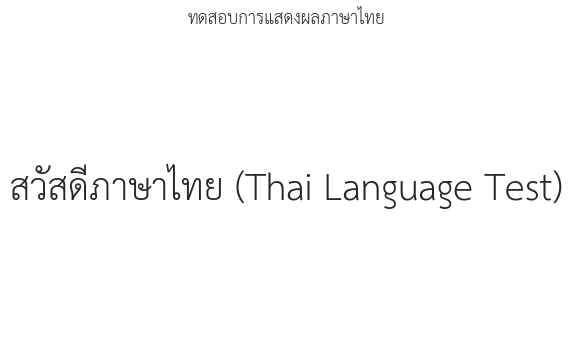

In [ ]:
# ดาวน์โหลดฟอนต์ TH Sarabun New
!wget -q https://github.com/Phonbopit/sarabun-webfont/\
raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# เพิ่มฟอนต์เข้าระบบ Matplotlib
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
# ตั้งค่า default font ให้เป็น TH Sarabun New
mpl.rc('font', family='TH Sarabun New')

# ทดสอบการพล็อตภาษาไทย
plt.figure(figsize=(6, 4))
plt.text(0.5, 0.5, 'สวัสดีภาษาไทย (Thai Language Test)', fontsize=25, ha='center', va='center')
plt.title('ทดสอบการแสดงผลภาษาไทย')
plt.axis('off')
plt.show()

### 1. กราฟแท่ง (Bar Chart)
**คำถามเชิงนโยบายที่ตอบได้:** พื้นที่ใด (จังหวัด) ที่มีจำนวนผู้รับบริการมากที่สุด? เพื่อให้ผู้บริหารสามารถจัดสรรทรัพยากร งบประมาณ หรืออัตรากำลังเจ้าหน้าที่ไปยังพื้นที่ที่มีความต้องการสูงสุดได้อย่างเหมาะสม

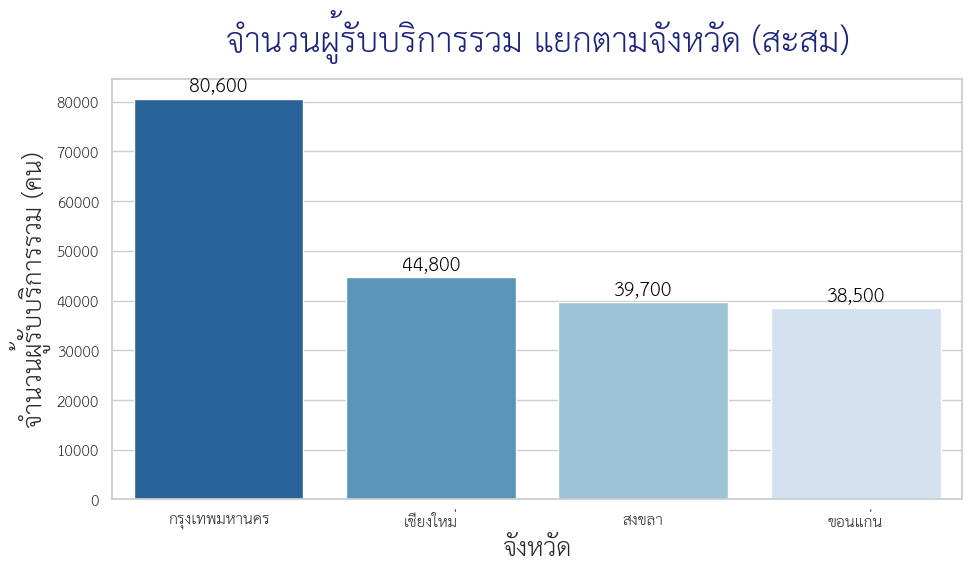

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# โหลดข้อมูล
url = "https://raw.githubusercontent.com/toche7/DataSets/main/session-03-workshop-sample-data.csv"
df = pd.read_csv(url)

# ตั้งค่าฟอนต์ภาษาไทยและสไตล์กราฟ
sns.set_theme(style="whitegrid", rc={"font.family": "TH Sarabun New"})
plt.rcParams.update({'font.size': 16})

# สรุปข้อมูลผู้รับบริการรวมรายจังหวัด
bar_data = df.groupby('จังหวัด')['จำนวนผู้รับบริการทั้งหมด(คน)'].sum().reset_index()
bar_data = bar_data.sort_values('จำนวนผู้รับบริการทั้งหมด(คน)', ascending=False)

# สร้างกราฟ
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bar_data, x='จังหวัด', y='จำนวนผู้รับบริการทั้งหมด(คน)', hue='จังหวัด', palette='Blues_r', legend=False)

# ตกแต่งกราฟ (Executive Style)
plt.title('จำนวนผู้รับบริการรวม แยกตามจังหวัด (สะสม)', fontsize=24, fontweight='bold', color='#1a237e', pad=20)
plt.xlabel('จังหวัด', fontsize=18)
plt.ylabel('จำนวนผู้รับบริการรวม (คน)', fontsize=18)

# ใส่ตัวเลขกำกับบนกราฟแท่ง
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=14, color='black')

plt.tight_layout()
plt.show()

### 2. กราฟเส้น (Line Chart)
**คำถามเชิงนโยบายที่ตอบได้:** แนวโน้มการให้บริการในภาพรวมตลอดระยะเวลาที่ผ่านมาเป็นอย่างไร? ความต้องการเพิ่มขึ้นหรือลดลง เพื่อเตรียมแผนรับมือในอนาคต (Forecasting)

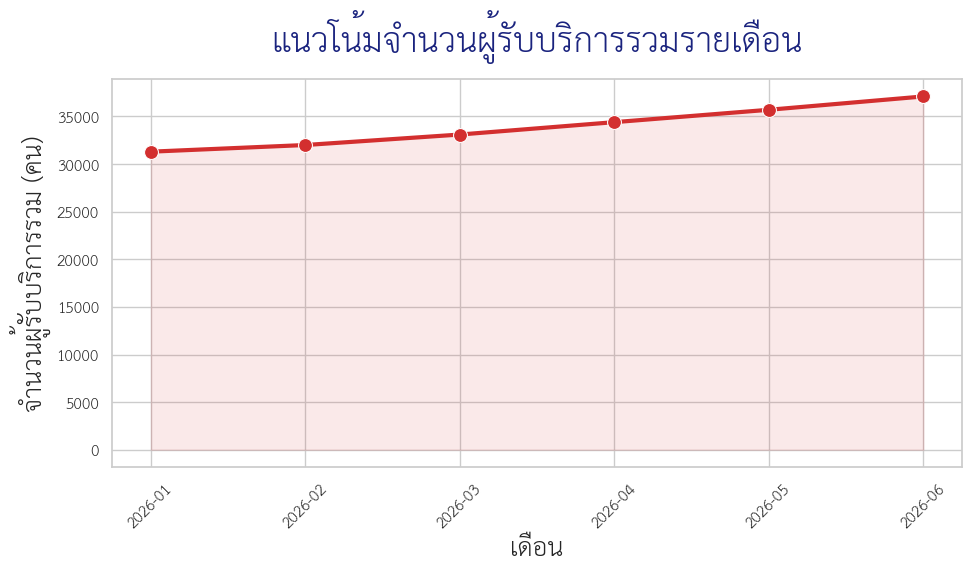

In [ ]:
# สรุปข้อมูลตามเดือน (แนวโน้มภาพรวม)
line_data = df.groupby('เดือน')['จำนวนผู้รับบริการทั้งหมด(คน)'].sum().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=line_data, x='เดือน', y='จำนวนผู้รับบริการทั้งหมด(คน)',
                  marker='o', markersize=10, color='#d32f2f', linewidth=3)

plt.title('แนวโน้มจำนวนผู้รับบริการรวมรายเดือน', fontsize=24, fontweight='bold', color='#1a237e', pad=20)
plt.xlabel('เดือน', fontsize=18)
plt.ylabel('จำนวนผู้รับบริการรวม (คน)', fontsize=18)
plt.xticks(rotation=45)

# เติมพื้นที่ใต้กราฟเล็กน้อยให้ดูสวยงาม
plt.fill_between(line_data['เดือน'], line_data['จำนวนผู้รับบริการทั้งหมด(คน)'], alpha=0.1, color='#d32f2f')

plt.tight_layout()
plt.show()

### 3. กราฟจุด (Scatter Plot)
**คำถามเชิงนโยบายที่ตอบได้:** ระยะเวลารอคอยเฉลี่ยส่งผลกระทบต่อระดับความพึงพอใจของประชาชนหรือไม่? หากระยะเวลารอคอยนานขึ้น ความพึงพอใจจะลดลงอย่างมีนัยสำคัญหรือไม่ เพื่อนำไปสู่การปรับปรุงกระบวนการทำงาน

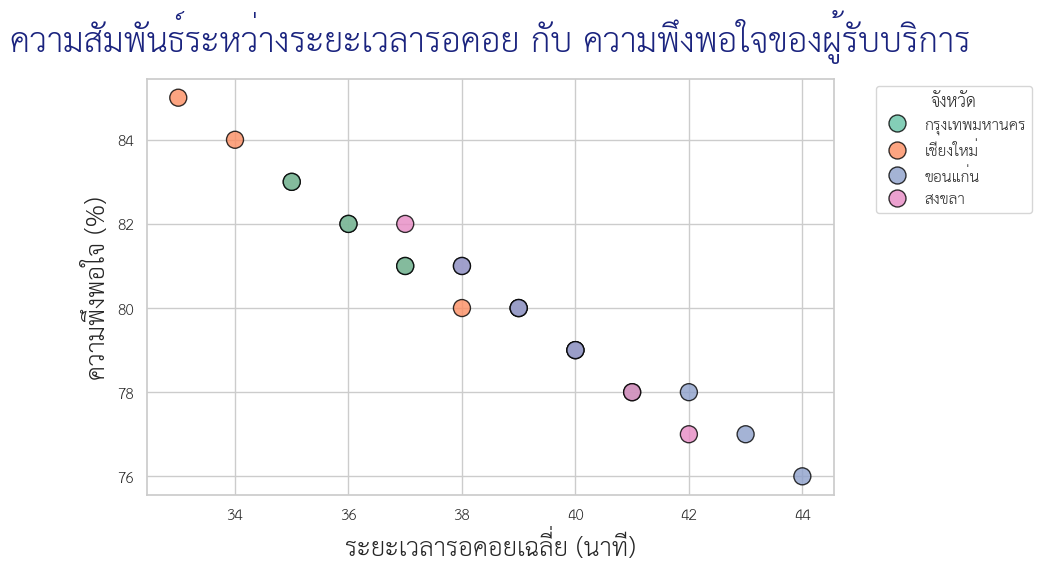

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='เวลารอเฉลี่ย(นาที)', y='ความพึงพอใจ(%)',
                hue='จังหวัด', palette='Set2', s=150, alpha=0.8, edgecolor='black')

plt.title('ความสัมพันธ์ระหว่างระยะเวลารอคอย กับ ความพึงพอใจของผู้รับบริการ',
          fontsize=24, fontweight='bold', color='#1a237e', pad=20)
plt.xlabel('ระยะเวลารอคอยเฉลี่ย (นาที)', fontsize=18)
plt.ylabel('ความพึงพอใจ (%)', fontsize=18)
plt.legend(title='จังหวัด', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 4. ตารางสีแสดงความร้อน (Heatmap)
**คำถามเชิงนโยบายที่ตอบได้:** ปัจจัยใดที่มีความสัมพันธ์ (Correlation) กันมากที่สุด? เช่น การเพิ่มช่องทางออนไลน์ช่วยลดเวลารอคอยหรือไม่ หรือปัจจัยใดเป็นตัวขับเคลื่อนหลักที่ทำให้ประชาชนพึงพอใจสูงสุด

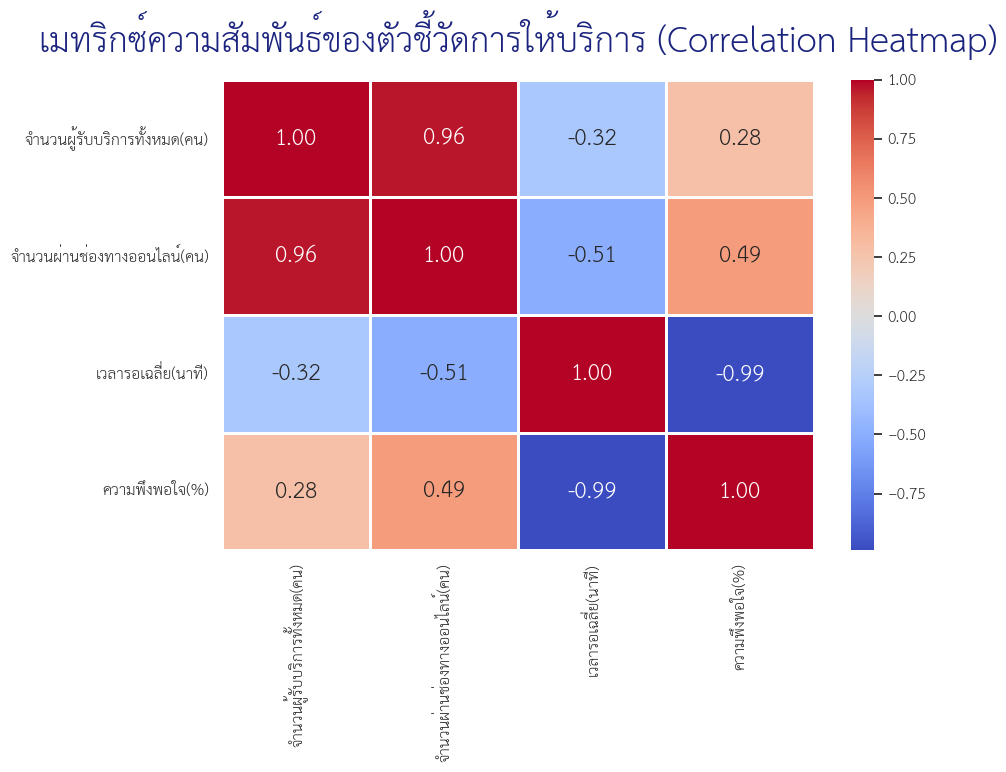

In [ ]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
num_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=2, linecolor='white', annot_kws={"size": 16})

plt.title('เมทริกซ์ความสัมพันธ์ของตัวชี้วัดการให้บริการ (Correlation Heatmap)',
          fontsize=24, fontweight='bold', color='#1a237e', pad=20)

plt.tight_layout()
plt.show()